In [310]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots, cm
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
import seaborn as sns

from sklearn.svm import SVC
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay

### Conceptual

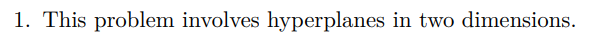

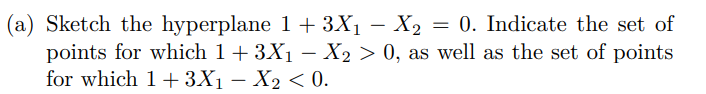

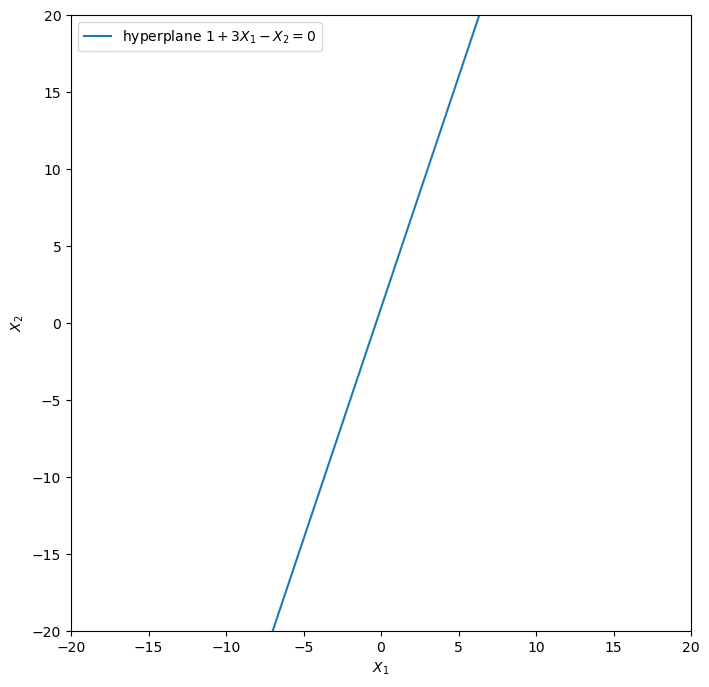

In [311]:
X_1 = np.linspace(-20, 20, 41)
X_2 = 1 + 3 * X_1

fig, ax = subplots(figsize=(8, 8))
ax.plot(X_1, X_2, label="hyperplane $1 + 3X_1 - X_2 = 0$")

ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.set_ylim(-20, 20)
ax.set_xlim(-20, 20)
ax.legend()

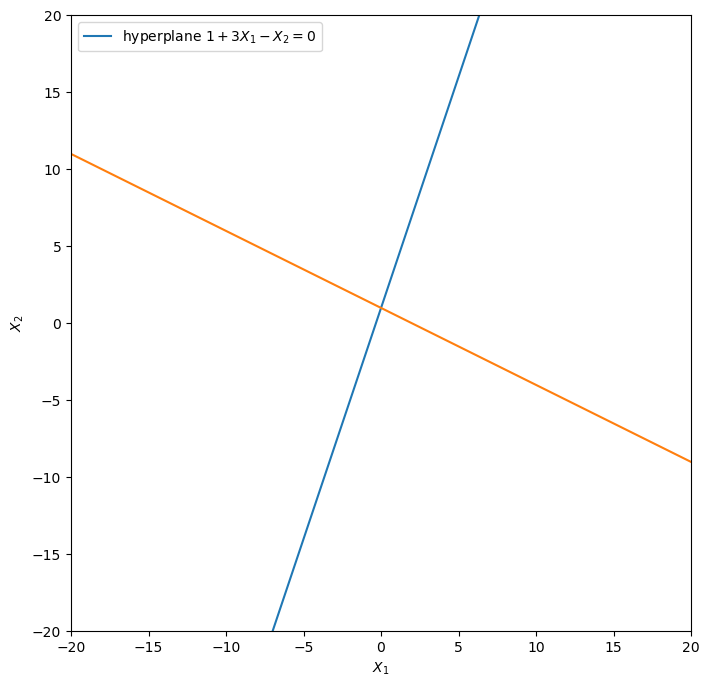

In [312]:
X_1 = np.linspace(-20, 20, 41)
X_2 = (-2  + X_1) / -2

ax.plot(X_1, X_2, label="hyperplane $-2 + X_1 + 2X_2 = 0$")

fig

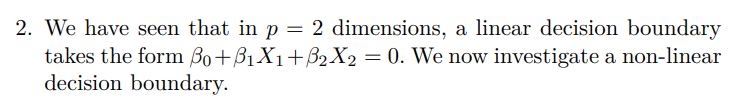

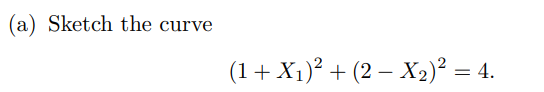

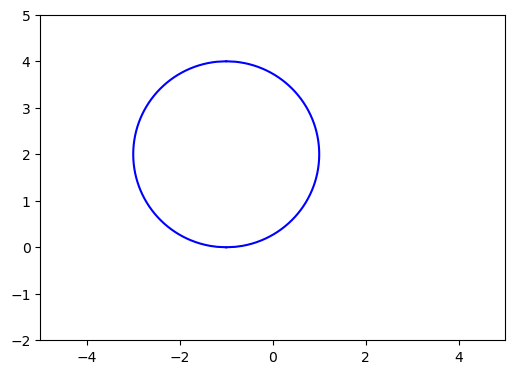

In [313]:
X_2 = np.linspace(0, 4, 400)
X_1_minus = -1 - np.sqrt(4 - (2 - X_2)**2)
X_1_plus = -1 + np.sqrt(4 - (2 - X_2)**2)

fig, ax = subplots(figsize=(6, 6))
ax.plot(X_1_minus, X_2, c="b")
ax.plot(X_1_plus, X_2, c="b")
ax.set_xlim(-5, 5)
ax.set_ylim(-2, 5)
ax.set_aspect("equal")

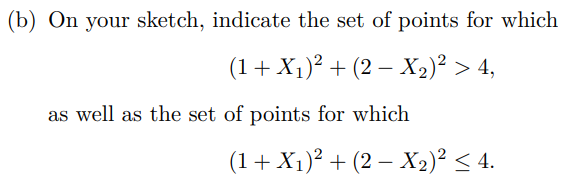

C:\Users\Admin\AppData\Local\Temp\ipykernel_17384\300627660.py:11: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contourf(X1, X2, expr, levels=[0, 4], colors=['lightcoral'], alpha=0.5, label='$(1 + X_1)^2 + (2 - X_2)^2 < 4$')
C:\Users\Admin\AppData\Local\Temp\ipykernel_17384\300627660.py:12: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contourf(X1, X2, expr, levels=[4, expr.max()], colors=['lightblue'], alpha=0.5, label='$(1 + X_1)^2 + (2 - X_2)^2 > 4$')


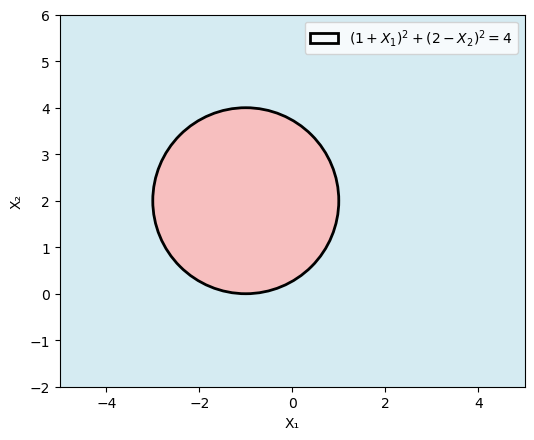

In [314]:
import matplotlib.pyplot as plt

x1 = np.linspace(-5, 5, 400)
x2 = np.linspace(-2, 6, 400)
X1, X2 = np.meshgrid(x1, x2)

expr = (1 + X1)**2 + (2 - X2)**2

fig, ax = plt.subplots(figsize=(6, 6))

ax.contourf(X1, X2, expr, levels=[0, 4], colors=['lightcoral'], alpha=0.5, label='$(1 + X_1)^2 + (2 - X_2)^2 < 4$')
ax.contourf(X1, X2, expr, levels=[4, expr.max()], colors=['lightblue'], alpha=0.5, label='$(1 + X_1)^2 + (2 - X_2)^2 > 4$')  
circle = plt.Circle((-1, 2), 2, color='k', fill=False, linewidth=2, label='$(1 + X_1)^2 + (2 - X_2)^2 = 4$')
ax.add_artist(circle)

ax.set_xlim(-5, 5)
ax.set_ylim(-2, 6)
ax.set_aspect('equal')

ax.set_xlabel('X₁')
ax.set_ylabel('X₂')
ax.legend()
plt.show()

In [315]:
X_test = [
  (0, 0),
  (-1, 1),
  (2, 2),
  (3, 8)
]

y_pred = []
for test_obs in X_test:
  X_1, X_2 = test_obs
  y_pred.append("blue" if (1 + X_1)**2 + (2 - X_2)**2 > 4 else "red")


In [316]:
y_pred

['blue', 'red', 'blue', 'blue']

C:\Users\Admin\AppData\Local\Temp\ipykernel_17384\1677276489.py:3: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contourf(X1, X2, expr, levels=[0, 4], colors=['lightcoral'], alpha=0.5, label='$(1 + X_1)^2 + (2 - X_2)^2 < 4$')
C:\Users\Admin\AppData\Local\Temp\ipykernel_17384\1677276489.py:4: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contourf(X1, X2, expr, levels=[4, expr.max()], colors=['lightblue'], alpha=0.5, label='$(1 + X_1)^2 + (2 - X_2)^2 > 4$')


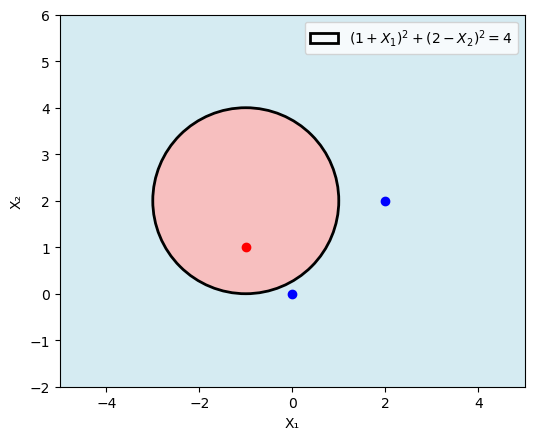

In [317]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.contourf(X1, X2, expr, levels=[0, 4], colors=['lightcoral'], alpha=0.5, label='$(1 + X_1)^2 + (2 - X_2)^2 < 4$')
ax.contourf(X1, X2, expr, levels=[4, expr.max()], colors=['lightblue'], alpha=0.5, label='$(1 + X_1)^2 + (2 - X_2)^2 > 4$')  
circle = plt.Circle((-1, 2), 2, color='k', fill=False, linewidth=2, label='$(1 + X_1)^2 + (2 - X_2)^2 = 4$')
ax.add_artist(circle)

ax.set_xlim(-5, 5)
ax.set_ylim(-2, 6)
ax.set_aspect('equal')

for idx, test_obs in enumerate(X_test):
  ax.scatter(test_obs[0], test_obs[1], c=y_pred[idx])

ax.set_xlabel('X₁')
ax.set_ylabel('X₂')
ax.legend()
plt.show()

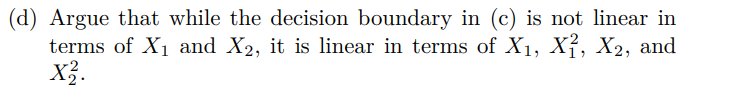

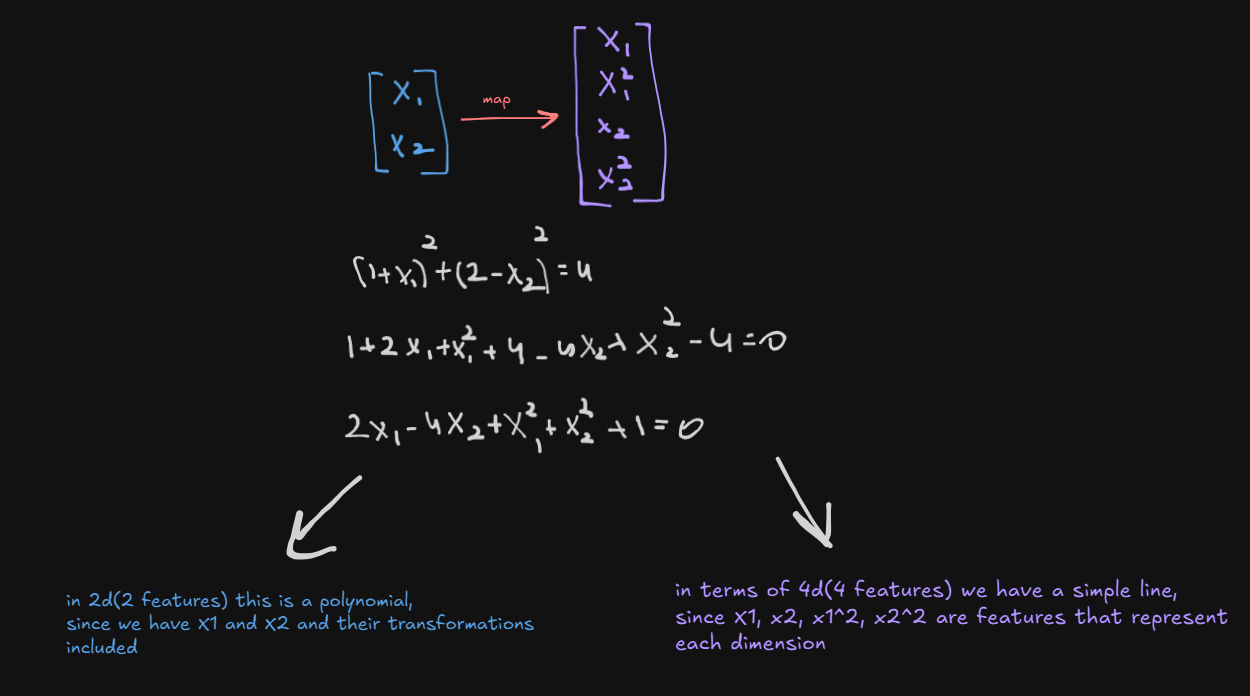

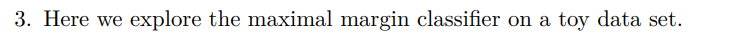

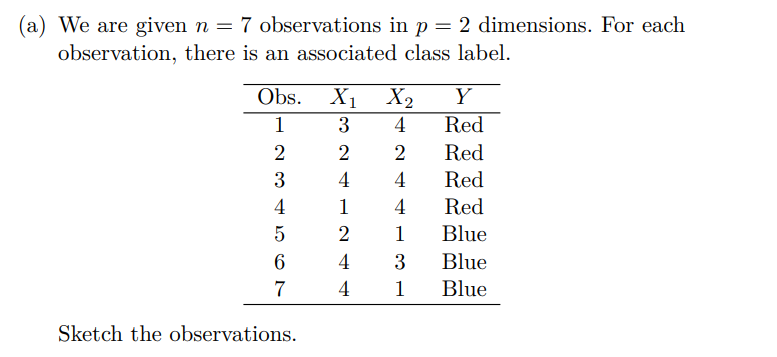

In [318]:
data = pd.DataFrame({
  "x1": [3, 2, 4, 1, 2, 4, 4],
  "x2": [4, 2, 4, 4, 1, 3, 1],
  "y": ["red", "red", "red", "red", "blue", "blue", "blue"]  
})
data

,x1,x2,y
0,3,4,red
1,2,2,red
2,4,4,red
3,1,4,red
4,2,1,blue
5,4,3,blue
6,4,1,blue


Text(0.5, 0, '$X_2$')

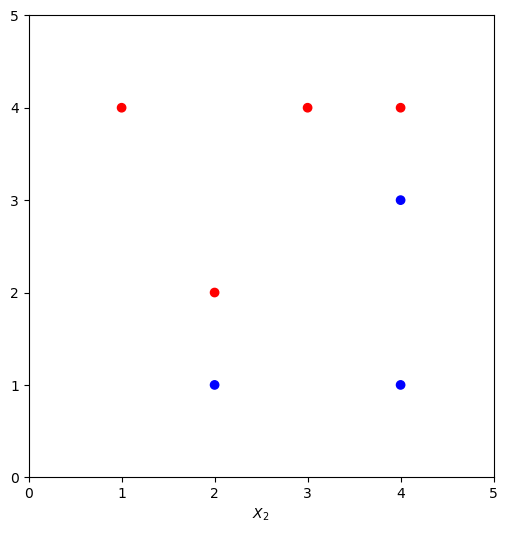

In [319]:
fig, ax = subplots(figsize=(6, 6))
plt.scatter(data["x1"],
            data["x2"],
            c=data["y"])
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_xlabel("$X_1$")
ax.set_xlabel("$X_2$")

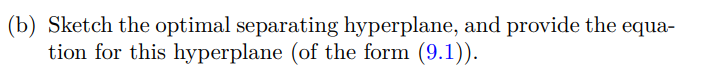

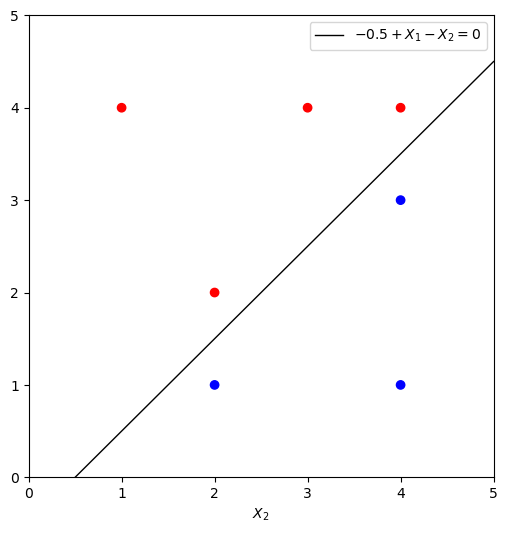

In [320]:
X_1 = np.linspace(0, 5, 100)
X_2 = -0.5 + X_1

ax.plot(X_1, X_2, c="black", linewidth=1, label="$-0.5 + X_1 - X_2 = 0$")
ax.legend()

fig

hyperplane:
$$-0.5 + X_1 - X_2 = 0$$

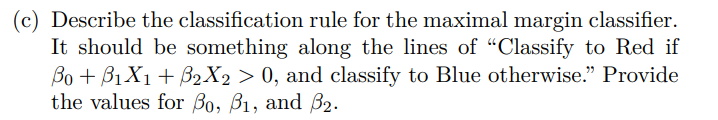

So, we have an equation of hyperplane:
$$\beta_0 + \beta_1X_1 - \beta_2X_2 = 0$$
$$-0.5 + X_1 - X_2 = 0$$
where:
- $\beta_0$ = -0.5
- $\beta_1$ = 1
- $\beta_2$ = 1

We have two classes: "red": 1 and "blue": 0

If observation is above hyperplane or mathematically:
$$-0.5 + X_1 - X_2 > 0$$
then observation will be classified as "red"
or if
$$-0.5 + X_1 - X_2 < 0$$
then observation will be classifed as "blue"


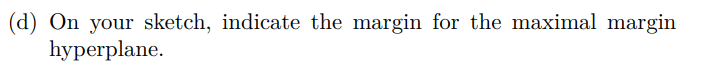

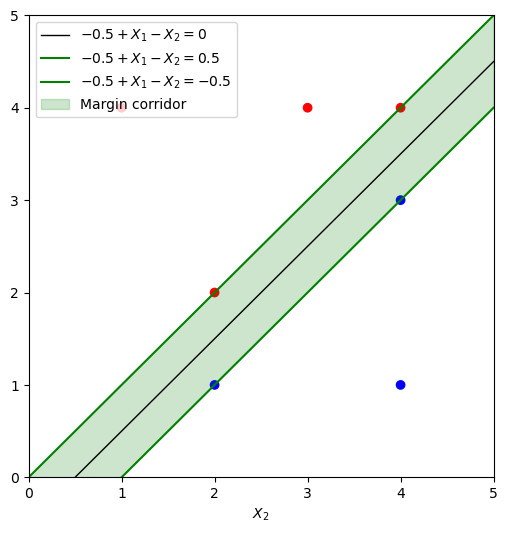

In [321]:
X_1 = np.linspace(0, 5, 100)
X_2 = -0.5 + X_1

lower = X_2 + 0.5
upper = X_2 - 0.5

ax.plot(X_1, upper, c="green", label="$-0.5 + X_1 - X_2 = 0.5$")
ax.plot(X_1, lower, c="green", label="$-0.5 + X_1 - X_2 = -0.5$")

ax.fill_between(X_1, lower, upper, color="green", alpha=0.2, label="Margin corridor")

ax.legend()
fig

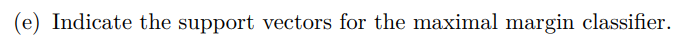

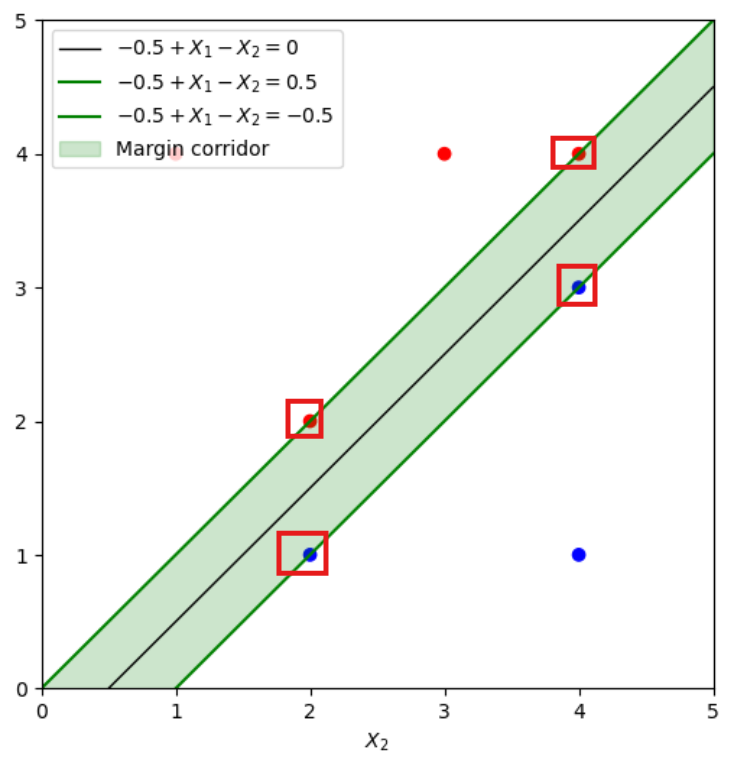

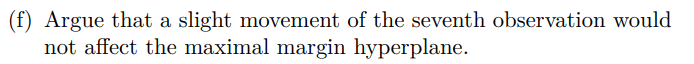

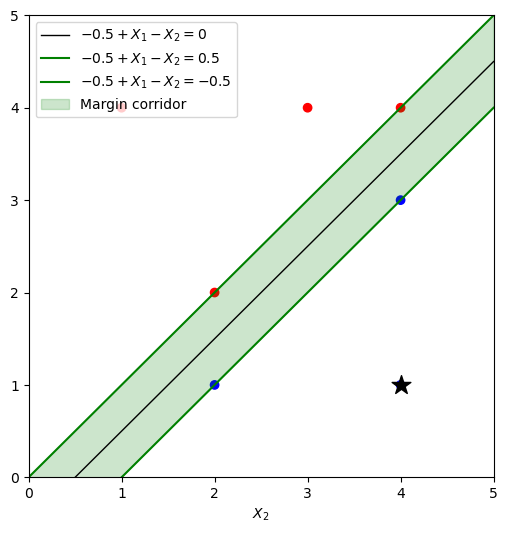

In [322]:
obs = data.iloc[-1]
ax.scatter(obs["x1"], obs["x2"], c="black", marker="*", s=200, label="observation")
fig

Here we see, that seventh observation is not a support vector, and from thery we know, that very crucial feature of maximal margin classifier(and as consequence in SVC and SVM): only support vectors can affect the hyperplane

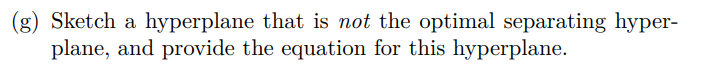

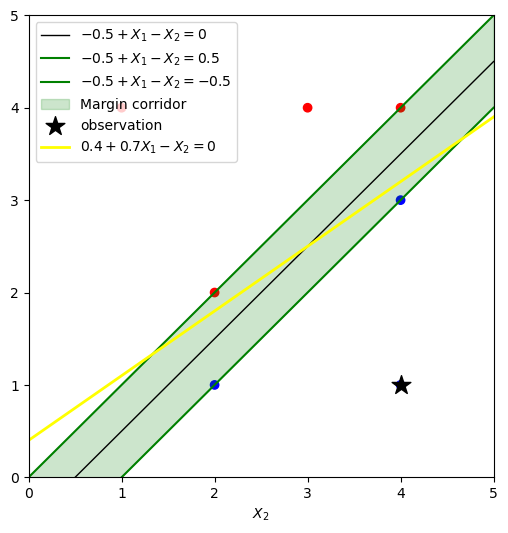

In [323]:
X_1 = np.linspace(0, 5, 100)
X_2 = 0.4 + 0.7 * X_1

ax.plot(X_1, X_2, c="yellow", linewidth=2, label="$0.4 + 0.7X_1 - X_2 = 0$")

ax.legend()
fig

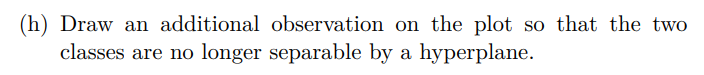

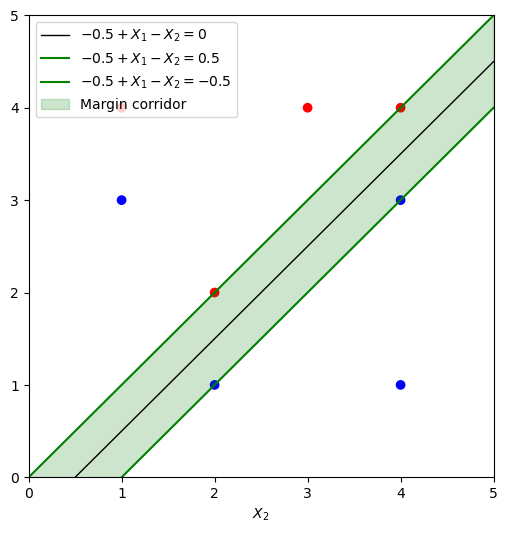

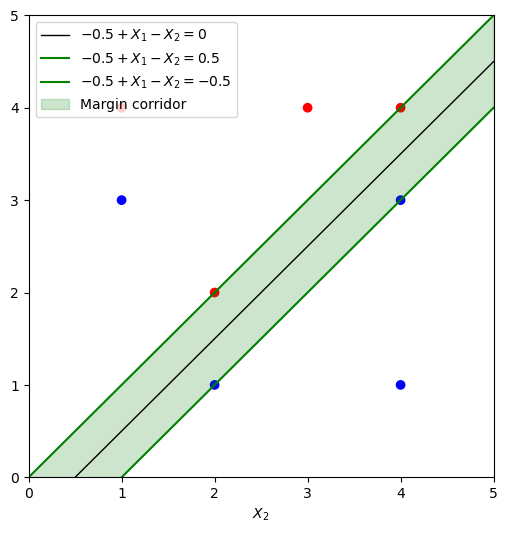

In [324]:
data.loc[len(data)] = [1, 3, "blue"]

fig, ax = subplots(figsize=(6, 6))
plt.scatter(data["x1"],
            data["x2"],
            c=data["y"])
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_xlabel("$X_1$")
ax.set_xlabel("$X_2$")

X_1 = np.linspace(0, 5, 100)
X_2 = -0.5 + X_1

ax.plot(X_1, X_2, c="black", linewidth=1, label="$-0.5 + X_1 - X_2 = 0$")
ax.legend()

lower = X_2 + 0.5
upper = X_2 - 0.5

ax.plot(X_1, upper, c="green", label="$-0.5 + X_1 - X_2 = 0.5$")
ax.plot(X_1, lower, c="green", label="$-0.5 + X_1 - X_2 = -0.5$")

ax.fill_between(X_1, lower, upper, color="green", alpha=0.2, label="Margin corridor")

ax.legend()
fig

### Applied

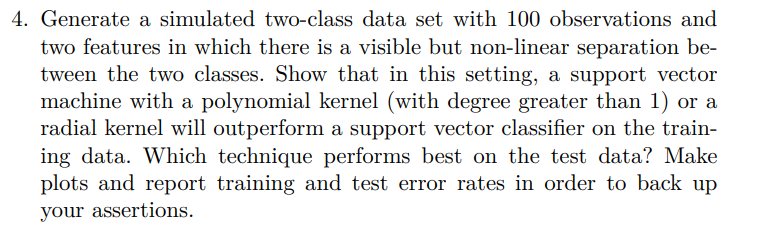

In [325]:
rng = np.random.default_rng(0)
X = rng.standard_normal((100, 2))
X.shape

(100, 2)

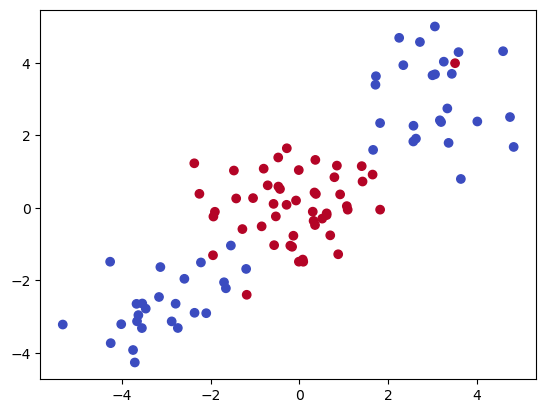

In [326]:
X[:25] -= 3
X[25:51] +=3
y = np.array([-1] * 50 + [1] * 50)

plt.scatter(X[:, 0],
           X[:, 1],
           c=y,
           cmap=cm.coolwarm)

In [327]:
X_train, X_test, y_train, y_test = skm.train_test_split(X, y, test_size=0.2, random_state=42)

Truth,-1,1
Predicted,,
-1,0,0
1,12,8


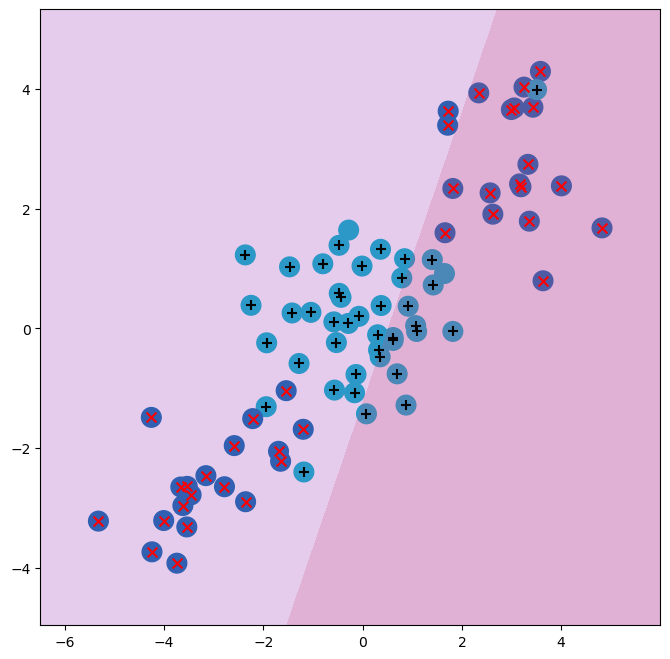

In [328]:
linear_svm = SVC(kernel="linear")
linear_svm.fit(X_train, y_train)

fig, ax = subplots(figsize=(8, 8))
plot_svm(X_train,
         y_train,
         linear_svm,
         ax=ax)

y_pred = linear_svm.predict(X_test)

confusion_table(y_pred, y_test)

In [329]:
kfold = skm.KFold(n_splits=5,
                  random_state=0,
                  shuffle=True)

param_grid = {
  "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid = skm.GridSearchCV(linear_svm,
                        param_grid=param_grid,
                        cv=kfold,
                        scoring="accuracy",
                        refit=True)

grid.fit(X_train, y_train)
grid.best_params_

{'C': 1}

In [330]:
from sklearn.metrics import accuracy_score

Test accuracy:  0.4
Train accuracy:  0.525


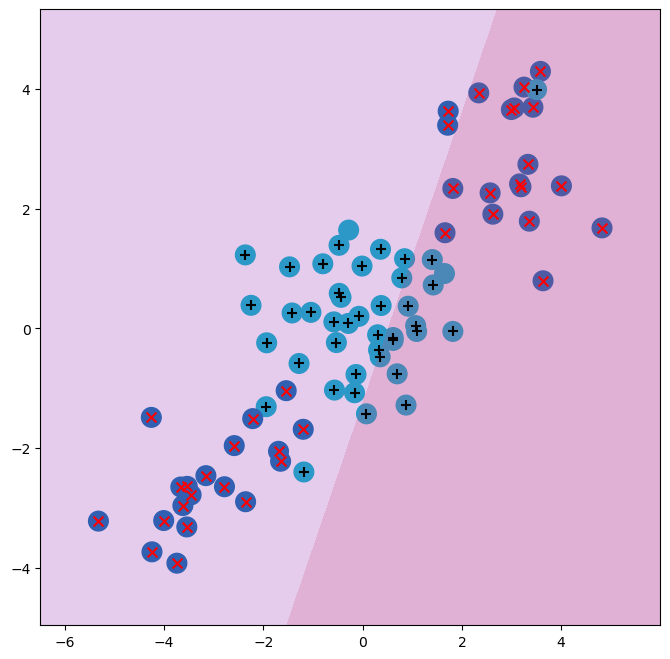

In [331]:
best_linear_svm = grid.best_estimator_

fig, ax = subplots(figsize=(8, 8))
plot_svm(X_train,
         y_train,
         best_linear_svm,
         ax=ax)

y_test_pred = best_linear_svm.predict(X_test)
y_train_pred = best_linear_svm.predict(X_train)


confusion_table(y_pred, y_test) 
print("Test accuracy: ", accuracy_score(y_test, y_test_pred))
print("Train accuracy: ", accuracy_score(y_train, y_train_pred))

We see bad perfomance of linear kernel(SVC) and this is obvious since data is not linear separable

In [332]:
poly_svm = SVC(kernel="poly")
poly_svm.fit(X_train, y_train)

SVC(kernel='poly')

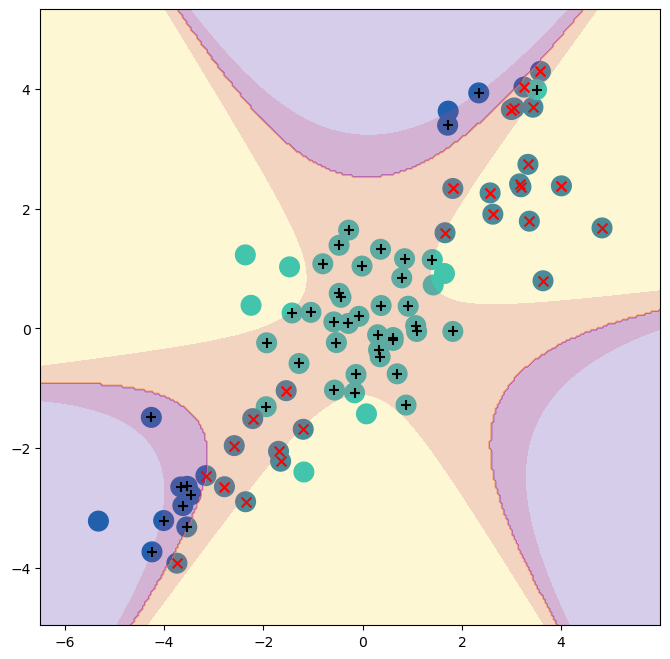

In [333]:
fig, ax = subplots(figsize=(8, 8))
plot_svm(X_train,
         y_train,
         poly_svm,
         ax=ax)

In [334]:
kfold = skm.KFold(n_splits=5,
                  random_state=0,
                  shuffle=True)

param_grid = {
  "degree": [2, 3, 4, 5, 6, 7],
  "C": [0.001, 0.01, 0.1, 1, 5, 10, 100]
}

grid = skm.GridSearchCV(poly_svm,
                        param_grid=param_grid,
                        cv=kfold,
                        refit=True,
                        scoring="accuracy")

grid.fit(X_train, y_train)
grid.best_params_

{'C': 1, 'degree': 2}

Truth      -1   1
Predicted        
-1          0   0
 1         12   8
Test accuracy:  1.0
Train accuracy:  0.95


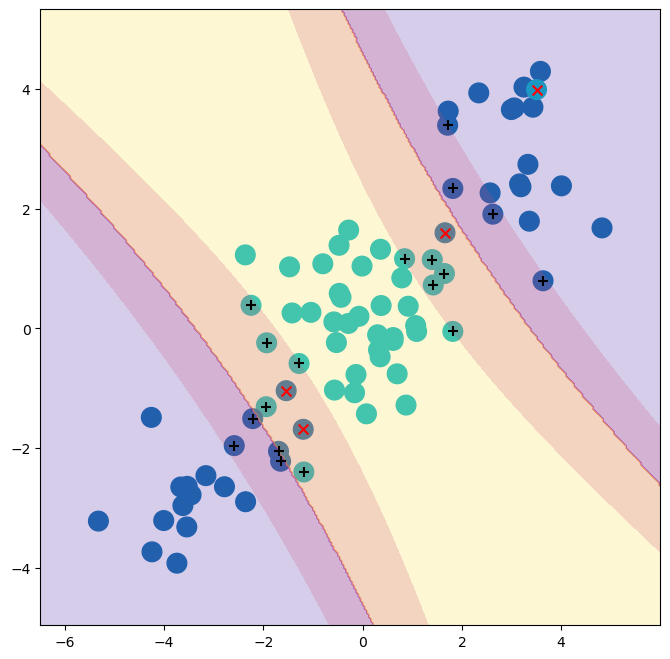

In [335]:
best_poly_svm = grid.best_estimator_

fig, ax = subplots(figsize=(8, 8))
plot_svm(X_train,
         y_train,
         best_poly_svm,
         ax=ax)

y_test_pred = best_poly_svm.predict(X_test)
y_train_pred = best_poly_svm.predict(X_train)


print(confusion_table(y_pred, y_test))
print("Test accuracy: ", accuracy_score(y_test, y_test_pred))
print("Train accuracy: ", accuracy_score(y_train, y_train_pred))

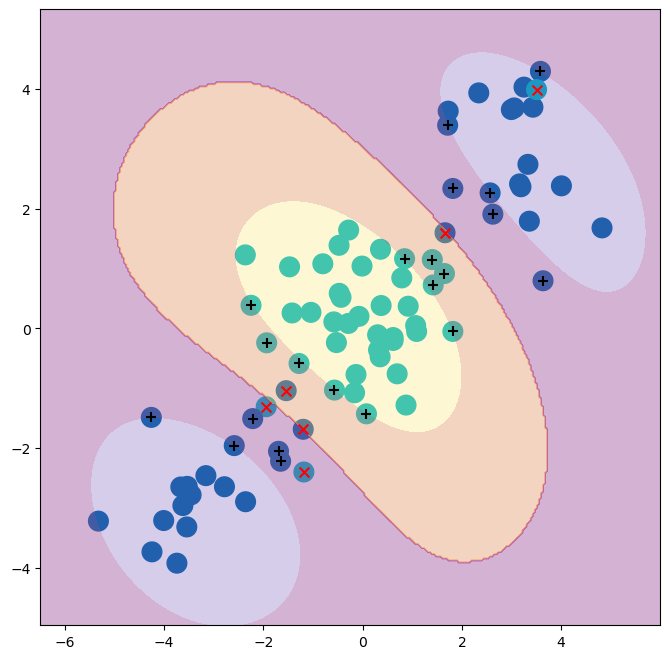

In [336]:
radial_svm = SVC(kernel="rbf")
radial_svm.fit(X_train, y_train)

fig, ax = subplots(figsize=(8, 8))
plot_svm(X_train,
         y_train,
         radial_svm,
         ax=ax)

In [337]:
kfold = skm.KFold(n_splits=5,
                  random_state=0,
                  shuffle=True)

param_grid = {
  "C": [0.001, 0.01, 0.1, 1, 5, 10, 100]
}

grid = skm.GridSearchCV(radial_svm,
                        param_grid=param_grid,
                        cv=kfold,
                        refit=True,
                        scoring="accuracy")

grid.fit(X_train, y_train)
grid.best_params_

{'C': 0.1}

Truth      -1   1
Predicted        
-1          0   0
 1         12   8
Test accuracy:  1.0
Train accuracy:  0.9375


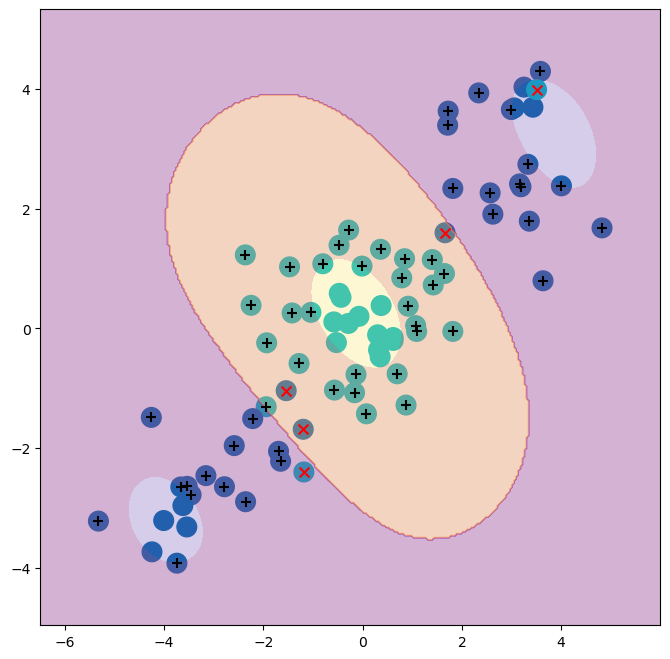

In [338]:
best_radial_svm = grid.best_estimator_

fig, ax = subplots(figsize=(8, 8))
plot_svm(X_train,
         y_train,
         best_radial_svm,
         ax=ax)

y_test_pred = best_radial_svm.predict(X_test)
y_train_pred = best_radial_svm.predict(X_train)


print(confusion_table(y_pred, y_test))
print("Test accuracy: ", accuracy_score(y_test, y_test_pred))
print("Train accuracy: ", accuracy_score(y_train, y_train_pred))

So, as we saw, SVM with polynomial and radial kernels showed the best results since the data was not linearly separable.

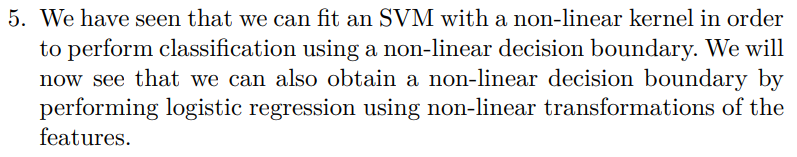

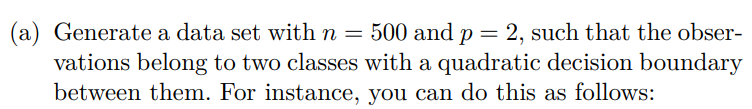

In [339]:
rng = np.random.default_rng(5)
x1 = rng.uniform(size=500) - 0.5
x2 = rng.uniform(size=500) - 0.5

y = x1**2 - x2**2 > 0

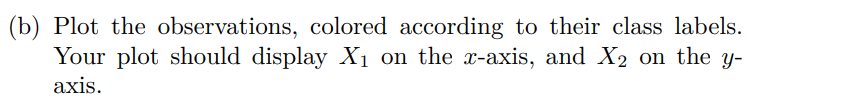

Text(0, 0.5, '$X_2$')

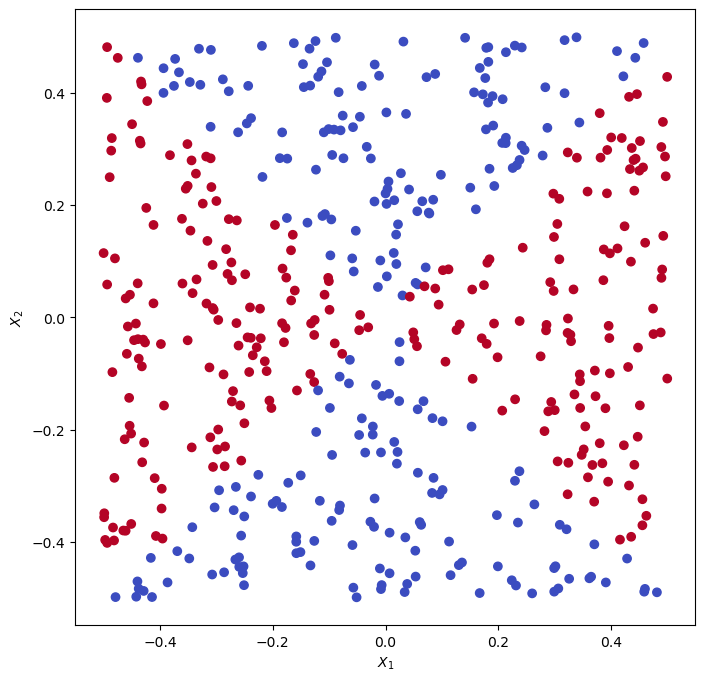

In [340]:
fig, ax = subplots(figsize=(8,8))
ax.scatter(x1,
           x2,
           c=y,
           cmap=cm.coolwarm)

ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")

In [341]:
from sklearn.linear_model import LogisticRegression

In [342]:
X = pd.DataFrame({
  "x1": x1,
  "x2": x2
})

log_regr = LogisticRegression().fit(X, y)

In [343]:
y_pred = log_regr.predict(X)

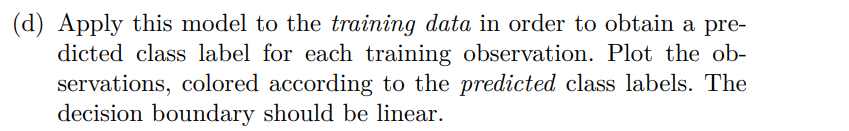

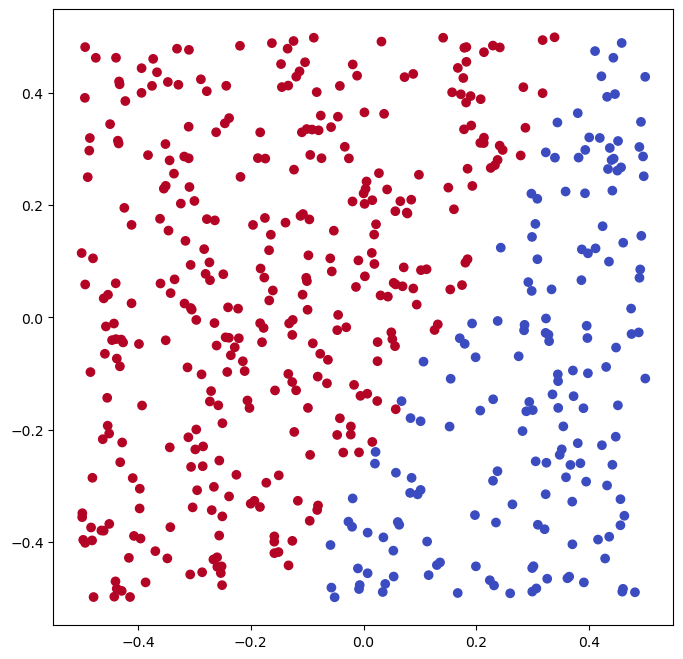

In [344]:
fig, ax = subplots(figsize=(8, 8))
ax.scatter(X["x1"],
           X["x2"],
           c=y_pred,
           cmap=cm.coolwarm)

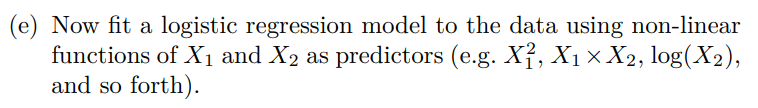

In [345]:
X["sin(x1)"] = np.sin(X["x1"])
X["x2^2"] = X["x2"]**2

X

,x1,x2,sin(x1),x2^2
0,0.305003,-0.256576,0.300296,0.065831
1,0.307941,0.211346,0.303097,0.044667
2,0.015326,0.208829,0.015325,0.043610
3,-0.214199,-0.078177,-0.212564,0.006112
4,-0.446069,-0.040580,-0.431423,0.001647
...,...,...,...,...
495,-0.094687,0.289493,-0.094545,0.083806
496,-0.259470,-0.444608,-0.256568,0.197676
497,-0.080933,-0.335240,-0.080844,0.112386
498,0.181635,0.382872,0.180638,0.146591


In [346]:
non_linear_log_regr = LogisticRegression().fit(X, y)
y_pred = non_linear_log_regr.predict(X)

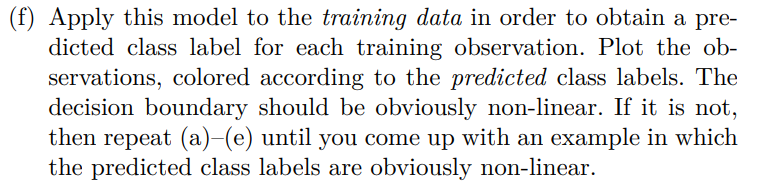

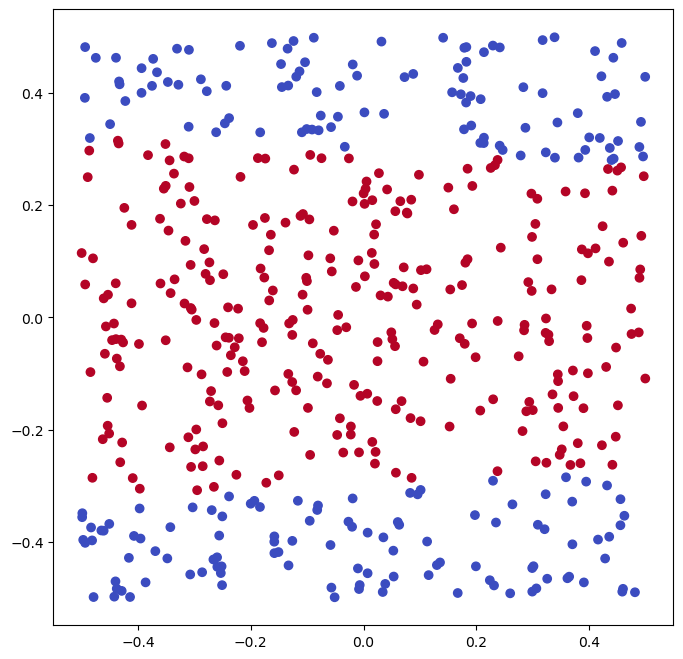

In [347]:
fig, ax = subplots(figsize=(8, 8))
ax.scatter(X["x1"],
           X["x2"],
           c=y_pred,
           cmap=cm.coolwarm)

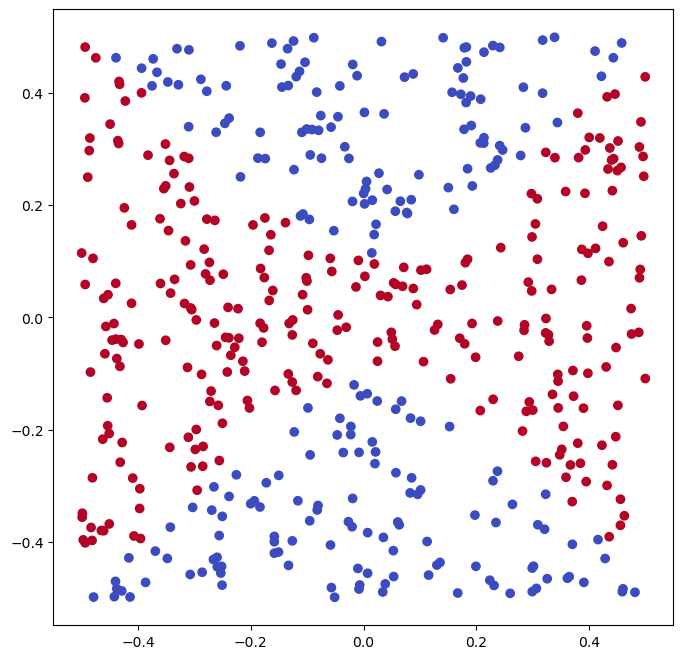

In [348]:
X = X.drop("sin(x1)", axis=1)
X["x1^2"] = X["x1"]**2
X["x2^2"] = X["x2"]**2

non_linear_log_regr = LogisticRegression().fit(X, y)
y_pred = non_linear_log_regr.predict(X)

fig, ax = subplots(figsize=(8, 8))
ax.scatter(X["x1"],
           X["x2"],
           c=y_pred,
           cmap=cm.coolwarm)

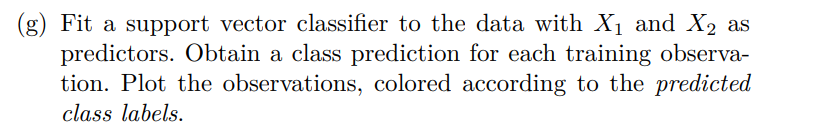

In [349]:
X = X.drop(["x1^2", "x2^2"], axis=1)

linear_svm = SVC(kernel="linear").fit(X, y)
y_pred = linear_svm.predict(X)

d:\Documents\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
d:\Documents\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
d:\Documents\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


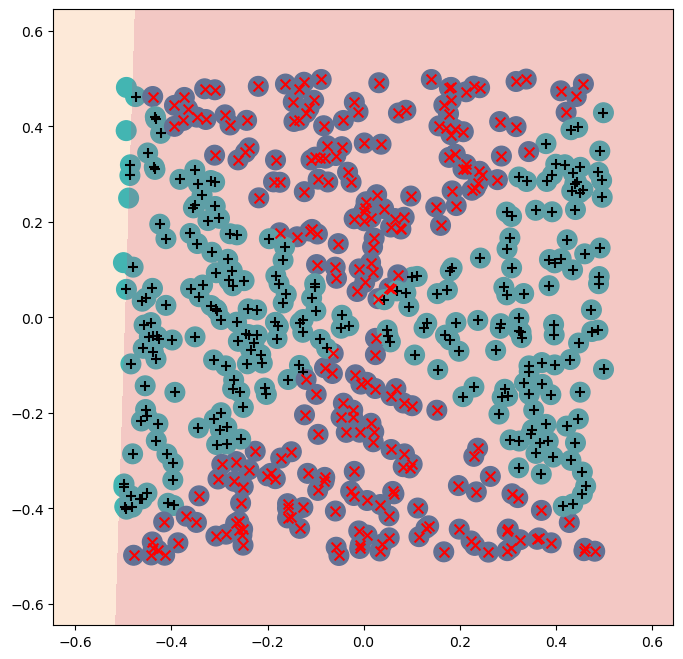

In [350]:
fig, ax = subplots(figsize=(8, 8))
plot_svm(X,
         y,
         linear_svm,
         ax=ax)

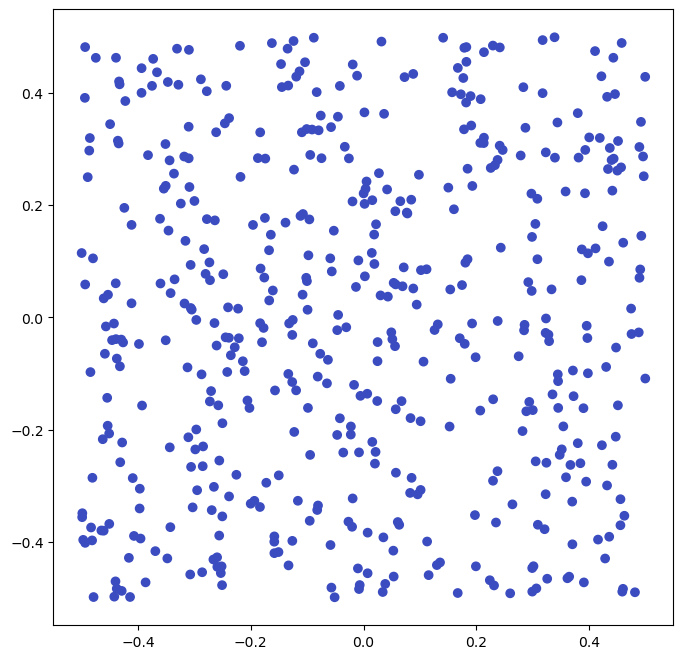

In [351]:
fig, ax = subplots(figsize=(8, 8))
ax.scatter(X["x1"],
           X["x2"],
           c=y_pred,
           cmap=cm.coolwarm)

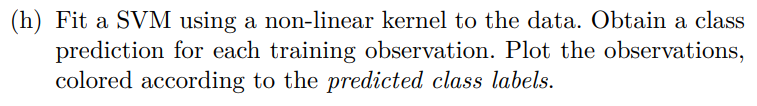

d:\Documents\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
d:\Documents\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
d:\Documents\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


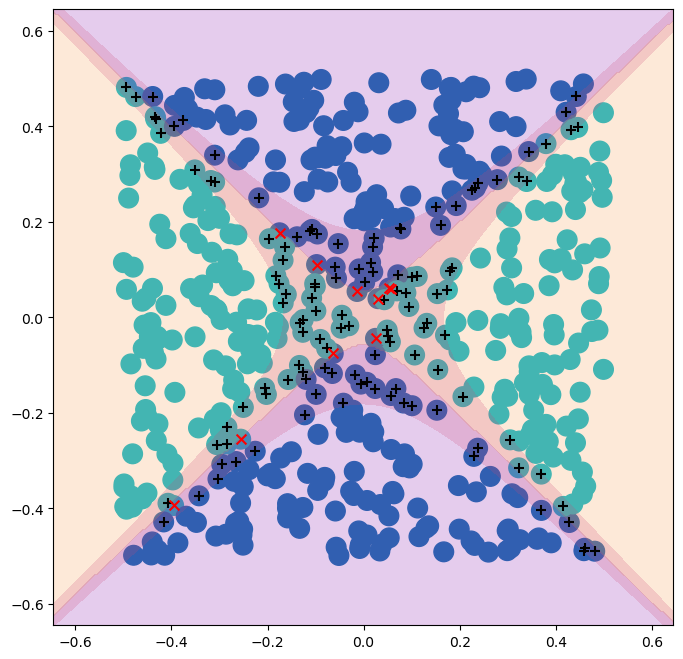

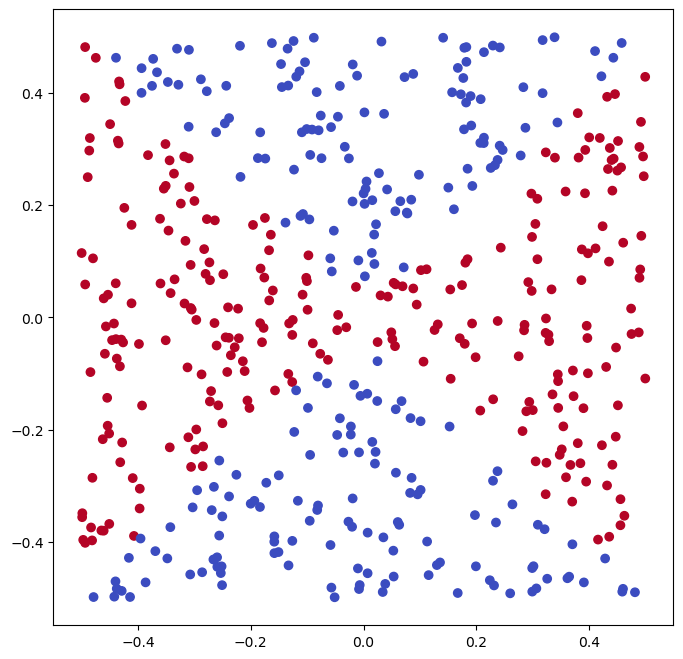

In [352]:
poly_svm = SVC(kernel="poly", degree=2).fit(X,y)
y_pred = poly_svm.predict(X)

fig, ax = subplots(figsize=(8, 8))
plot_svm(X,
         y,
         poly_svm,
         ax=ax)

fig, ax = subplots(figsize=(8, 8))
ax.scatter(X["x1"],
           X["x2"],
           c=y_pred,
           cmap=cm.coolwarm)

d:\Documents\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
d:\Documents\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
d:\Documents\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


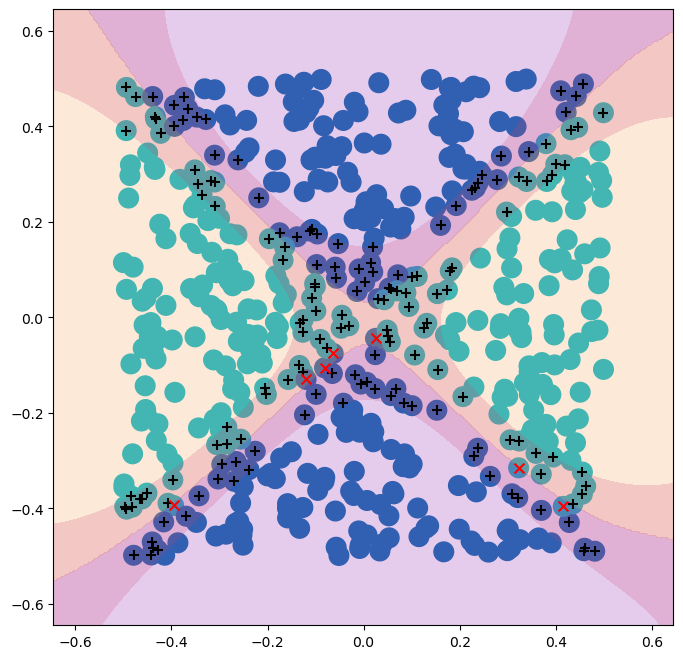

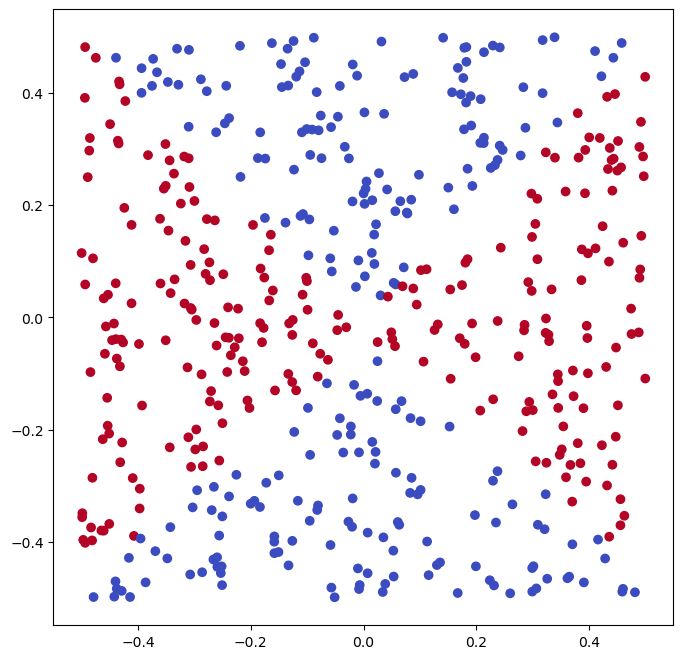

In [353]:
radial_svm = SVC(kernel="rbf").fit(X,y)
y_pred = radial_svm.predict(X)

fig, ax = subplots(figsize=(8, 8))
plot_svm(X,
         y,
         radial_svm,
         ax=ax)

fig, ax = subplots(figsize=(8, 8))
ax.scatter(X["x1"],
           X["x2"],
           c=y_pred,
           cmap=cm.coolwarm)

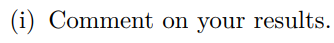

From explorations above, what can i say:
- Logistic regression with linear decision boundary(using X1, X2) and SVC(using linear kernel) showed poor results since the original clsses were generated from non-linear function.
- Logistic regression with a non-linear decision boundary(using original + tranformed features), SVM with polynomial kernel(with degree = 2 since the original classes were generated from quadratic function) and SVM with radial kernel showed the best results, almost perfect, and this is not strange because only non-linearity can be used for this data distribution.

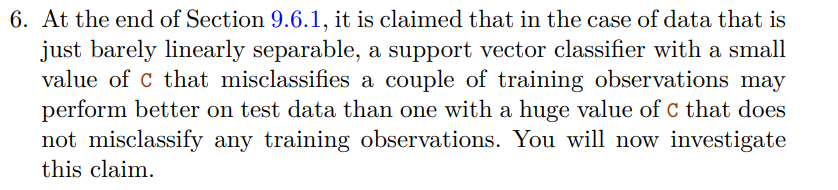

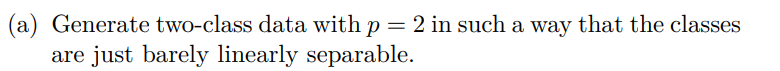

In [354]:
rng = np.random.default_rng(0)
X = rng.standard_normal((200, 2))
y = np.array([-1] * 100 + [1] * 100)

X[:100] += 3.3

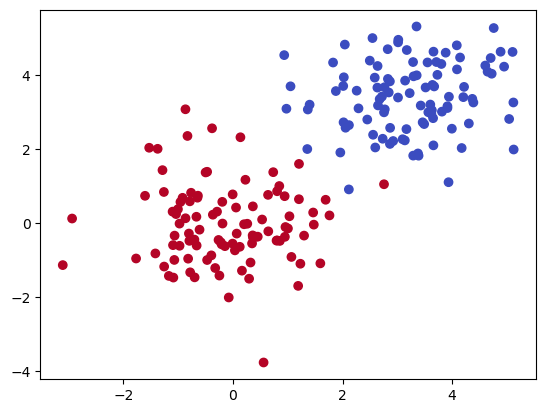

In [355]:
plt.scatter(X[:, 0],
            X[:, 1],
            c=y,
            cmap=cm.coolwarm)

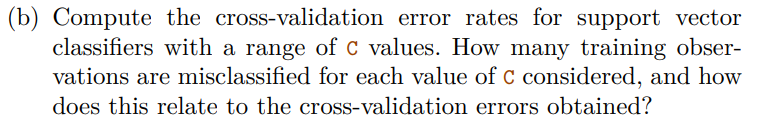

In [356]:
kfold = skm.KFold(n_splits=5,
                  random_state=0,
                  shuffle=True)

linear_svm = SVC(kernel="linear")

param_grid = {
  "C": [0.001, 0.01, 0.1, 1, 5, 10, 100]
}

grid = skm.GridSearchCV(linear_svm,
                        param_grid=param_grid,
                        cv=kfold,
                        scoring="accuracy",
                        refit=True)

grid.fit(X, y)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=SVC(kernel='linear'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]},
             scoring='accuracy')

In [357]:
grid.best_params_

{'C': 0.001}

In [358]:
scores = grid.cv_results_["mean_test_score"]
C_values = [p["C"] for p in grid.cv_results_["params"]]

for C, accuracy in zip(C_values, scores):
  print(f"C: {C} \nAccuracy: {accuracy}\n\n")

C: 0.001 
Accuracy: 0.99


C: 0.01 
Accuracy: 0.99


C: 0.1 
Accuracy: 0.99


C: 1 
Accuracy: 0.985


C: 5 
Accuracy: 0.99


C: 10 
Accuracy: 0.99


C: 100 
Accuracy: 0.99




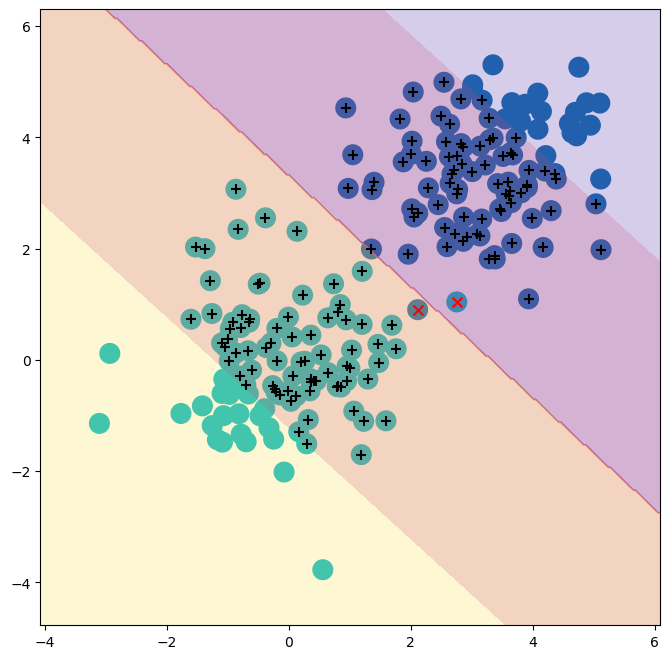

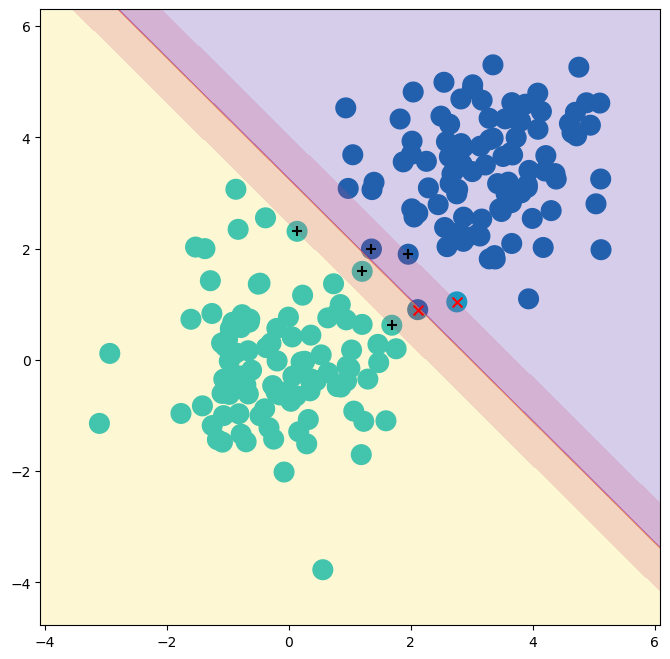

In [359]:
for C in [0.001, 5]:
  linear_svm = SVC(kernel="linear", C=C).fit(X, y)
  fig, ax = subplots(figsize=(8,8))
  plot_svm(X,
           y,
           linear_svm,
           ax=ax)

We see that with small C - margin is huge, and using C=5 makes margin minimal

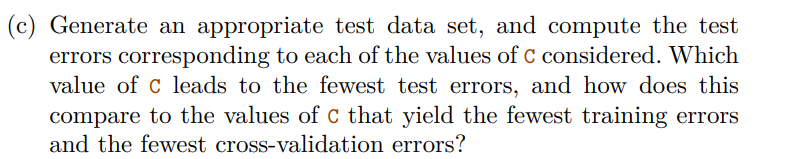

In [360]:
rng = np.random.default_rng(0)
X_test = rng.standard_normal((100, 2))
y_test = np.array([-1] * 50 + [1] * 50)

X_test[:50] += 2

In [361]:
for C in C_values:
  linear_svm = SVC(kernel="linear", C=C).fit(X, y)
  y_pred = linear_svm.predict(X_test)
  print("Test accuracy: ", accuracy_score(y_test, y_pred))
  

Test accuracy:  0.85
Test accuracy:  0.89
Test accuracy:  0.85
Test accuracy:  0.86
Test accuracy:  0.88
Test accuracy:  0.88
Test accuracy:  0.86


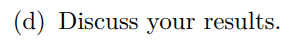

Big value of C makes model reduce number og misclassifications by reducing margin, whike small value of C allows maximizing.

The main point: huge C is not always great depsite small train error rate, this is TRAIN error rate, and we are interested at small TEST error rate. So, sometines we need to increase bias in order to reduce variance and have smaller errors in test data

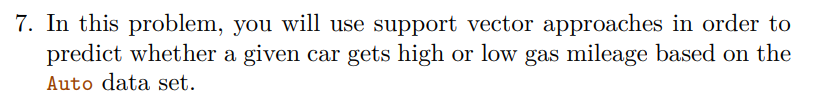

In [362]:
auto = load_data("Auto")
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


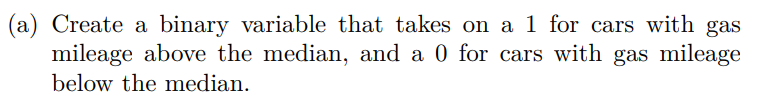

In [363]:
print(auto["mpg"].median())
print(auto["mpg"].std())
print(auto["mpg"].mean())

22.75
7.805007486571799
23.445918367346938


In [364]:
auto["mpg"] = (auto["mpg"] > auto["mpg"].median()).astype(int)
auto["mpg"].value_counts()

mpg
0    196
1    196
Name: count, dtype: int64

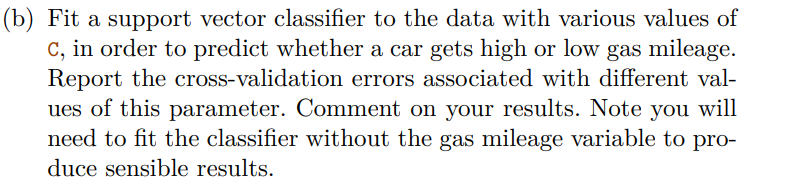

In [365]:
X = auto.drop("mpg", axis=1)
y = auto["mpg"]

In [366]:
kfold = skm.KFold(n_splits=5,
                  random_state=0,
                  shuffle=True)

a = np.linspace(0.001, 1, 10)
b = np.linspace(1, 100, 10)

C = np.concatenate((a, b))

param_grid = {
  "C": C
}

linear_svm = SVC(kernel="linear")

grid = skm.GridSearchCV(linear_svm,
                        param_grid=param_grid,
                        cv=kfold,
                        refit=True,
                        scoring="accuracy") 

grid.fit(X, y)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=SVC(kernel='linear'),
             param_grid={'C': array([1.00e-03, 1.12e-01, 2.23e-01, 3.34e-01, 4.45e-01, 5.56e-01,
       6.67e-01, 7.78e-01, 8.89e-01, 1.00e+00, 1.00e+00, 1.20e+01,
       2.30e+01, 3.40e+01, 4.50e+01, 5.60e+01, 6.70e+01, 7.80e+01,
       8.90e+01, 1.00e+02])},
             scoring='accuracy')

Text(0, 0.5, 'Accuracy')

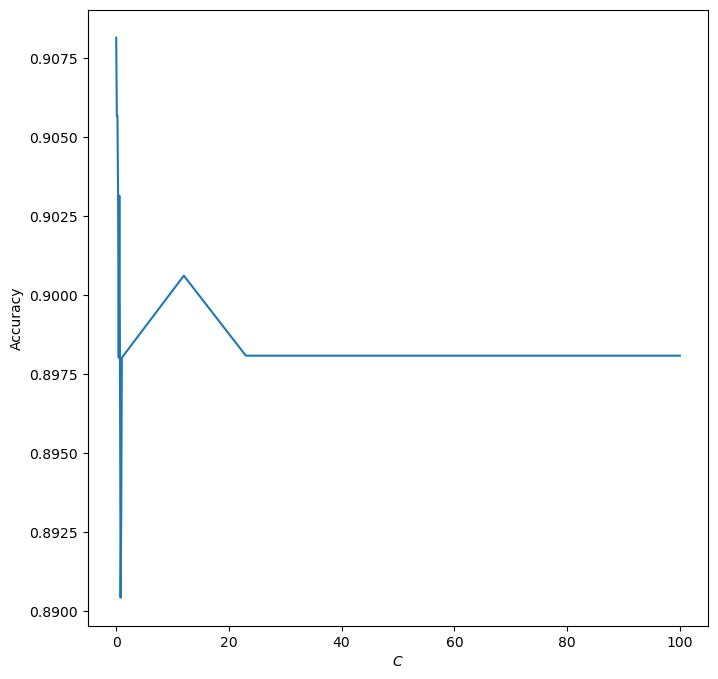

In [367]:
fig, ax = subplots(figsize=(8, 8))
ax.plot([p["C"] for p in grid.cv_results_["params"]],
        grid.cv_results_["mean_test_score"])

ax.set_xlabel("$C$")
ax.set_ylabel("Accuracy")

In [368]:
best_linear_svm = grid.best_estimator_
grid.best_params_

{'C': np.float64(0.001)}

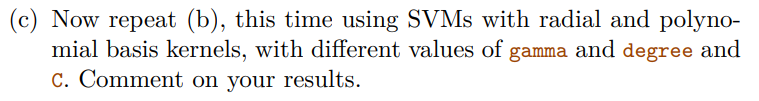

In [369]:
kfold = skm.KFold(n_splits=5,
                  random_state=0,
                  shuffle=True)

a = np.linspace(0.001, 1, 10)
b = np.linspace(1, 100, 10)

C = np.concatenate((a, b))

param_grid = {
  "C": C,
  "degree": np.linspace(2, 7, 6).astype(int)
}

poly_svm = SVC(kernel="poly")

grid = skm.GridSearchCV(poly_svm,
                        param_grid=param_grid,
                        cv=kfold,
                        refit=True,
                        scoring="accuracy") 

grid.fit(X, y)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=SVC(kernel='poly'),
             param_grid={'C': array([1.00e-03, 1.12e-01, 2.23e-01, 3.34e-01, 4.45e-01, 5.56e-01,
       6.67e-01, 7.78e-01, 8.89e-01, 1.00e+00, 1.00e+00, 1.20e+01,
       2.30e+01, 3.40e+01, 4.50e+01, 5.60e+01, 6.70e+01, 7.80e+01,
       8.90e+01, 1.00e+02]),
                         'degree': array([2, 3, 4, 5, 6, 7])},
             scoring='accuracy')

In [370]:
best_poly_svm = grid.best_estimator_
grid.best_params_

{'C': np.float64(89.0), 'degree': np.int64(3)}

In [371]:
results = pd.DataFrame(grid.cv_results_)
results = results[["param_C", "param_degree", "mean_test_score"]]
results

,param_C,param_degree,mean_test_score
0,0.001,2,0.431061
1,0.001,3,0.525868
2,0.001,4,0.698799
3,0.001,5,0.721779
4,0.001,6,0.744693
...,...,...,...
115,100.000,3,0.897988
116,100.000,4,0.895424
117,100.000,5,0.890295
118,100.000,6,0.892859


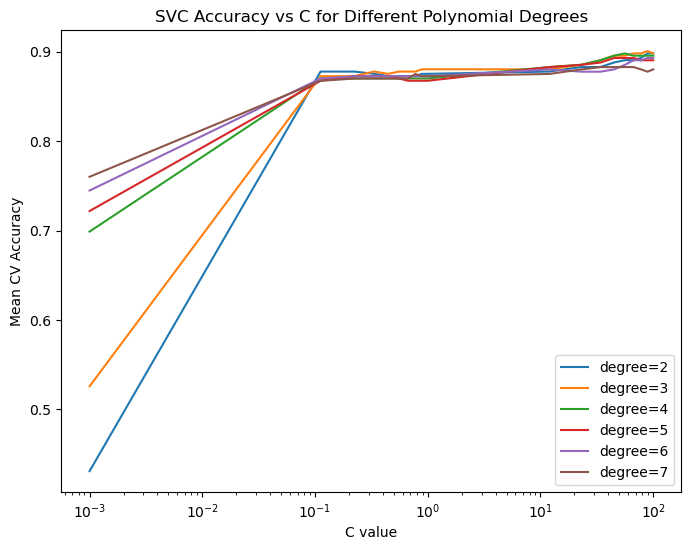

In [372]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))

for d in sorted(results["param_degree"].unique()):
    subset = results[results["param_degree"] == d]
    ax.plot(subset["param_C"], subset["mean_test_score"], label=f"degree={d}")

ax.set_xlabel("C value")
ax.set_ylabel("Mean CV Accuracy")
ax.set_title("SVC Accuracy vs C for Different Polynomial Degrees")
ax.legend()
ax.set_xscale("log") 
plt.show()


In [373]:
kfold = skm.KFold(n_splits=5,
                  random_state=0,
                  shuffle=True)

a = np.linspace(0.001, 1, 10)
b = np.linspace(1, 100, 10)

C = np.concatenate((a, b))

param_grid = {
  "C": C,
  "gamma": [1e-3, 1e-2, 1e-1, 1, 10]
}

radial_svm = SVC(kernel="rbf")

grid = skm.GridSearchCV(radial_svm,
                        param_grid=param_grid,
                        cv=kfold,
                        refit=True,
                        scoring="accuracy") 

grid.fit(X, y)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=SVC(),
             param_grid={'C': array([1.00e-03, 1.12e-01, 2.23e-01, 3.34e-01, 4.45e-01, 5.56e-01,
       6.67e-01, 7.78e-01, 8.89e-01, 1.00e+00, 1.00e+00, 1.20e+01,
       2.30e+01, 3.40e+01, 4.50e+01, 5.60e+01, 6.70e+01, 7.80e+01,
       8.90e+01, 1.00e+02]),
                         'gamma': [0.001, 0.01, 0.1, 1, 10]},
             scoring='accuracy')

In [374]:
best_radial_svm = grid.best_estimator_
grid.best_params_

{'C': np.float64(1.0), 'gamma': 0.001}

In [375]:
results = pd.DataFrame(grid.cv_results_)
results = results[["param_C", "param_gamma", "mean_test_score"]]
results

,param_C,param_gamma,mean_test_score
0,0.001,0.001,0.431061
1,0.001,0.010,0.431061
2,0.001,0.100,0.431061
3,0.001,1.000,0.431061
4,0.001,10.000,0.431061
...,...,...,...
95,100.000,0.001,0.869880
96,100.000,0.010,0.768160
97,100.000,0.100,0.477020
98,100.000,1.000,0.446381


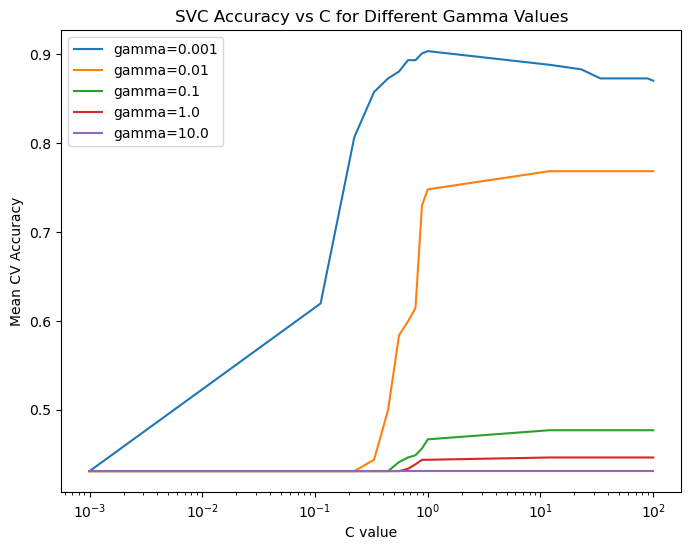

In [376]:
fig, ax = plt.subplots(figsize=(8,6))

for d in sorted(results["param_gamma"].unique()):
    subset = results[results["param_gamma"] == d]
    ax.plot(subset["param_C"], subset["mean_test_score"], label=f"gamma={d}")

ax.set_xlabel("C value")
ax.set_ylabel("Mean CV Accuracy")
ax.set_title("SVC Accuracy vs C for Different Gamma Values")
ax.legend()
ax.set_xscale("log") 
plt.show()

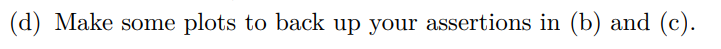

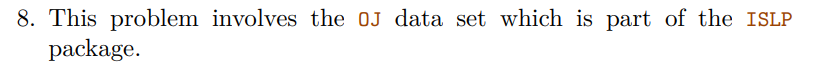

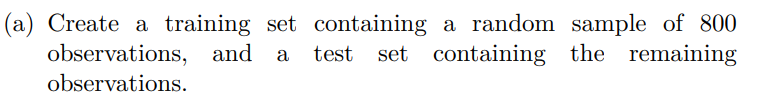

In [395]:
oj = load_data("OJ")
oj.head()

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


In [396]:
oj.shape

(1070, 18)

In [397]:
X = oj.drop("Purchase", axis=1)
y = oj["Purchase"]

In [390]:
from ISLP.models import ModelSpec as MS

In [398]:
X = MS(X.columns, intercept=False).fit_transform(oj)
X_train, X_test, y_train, y_test = skm.train_test_split(X, 
                                                        y,
                                                        train_size=800,
                                                        random_state=0)

In [399]:
X_train.shape

(800, 17)

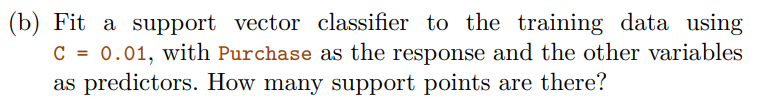

In [400]:
linear_svm = SVC(C=0.01, kernel="linear").fit(X_train, y_train)

In [402]:
linear_svm.support_vectors_.shape

(602, 17)

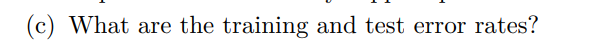

In [403]:
y_pred_train = linear_svm.predict(X_train)
y_pred_test = linear_svm.predict(X_test)

print(f"Train error rate: {1 - accuracy_score(y_train, y_pred_train)}")
print(f"Test error rate: {1 - accuracy_score(y_test, y_pred_test)}")

Train error rate: 0.28374999999999995
Test error rate: 0.3222222222222222


Test erorr is not differs a lot from train error since we have small C and a lot of support vectors that affect the data

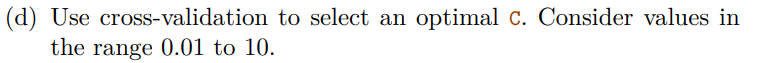

In [406]:
kfold = skm.KFold(n_splits=5,
                  random_state=0,
                  shuffle=True)

param_grid = {
  "C": [0.01, 0.1, 1, 5, 10]
}

grid = skm.GridSearchCV(linear_svm,
                        param_grid=param_grid,
                        cv=kfold,
                        refit=True,
                        scoring="accuracy") 

grid.fit(X, y)
grid.best_params_

{'C': 1}

In [407]:
best_linear_svm = grid.best_estimator_
best_linear_svm.support_vectors_.shape

(463, 17)

The number of support vectors is smaller since we used bigger `C` in order to decrease number of misclassifications and recude margin

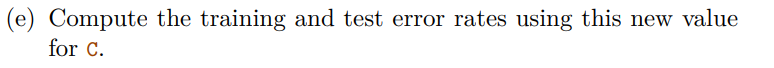

In [408]:
y_pred_train = best_linear_svm.predict(X_train)
y_pred_test = best_linear_svm.predict(X_test)

print(f"Train error rate: {1 - accuracy_score(y_train, y_pred_train)}")
print(f"Test error rate: {1 - accuracy_score(y_test, y_pred_test)}")

Train error rate: 0.15500000000000003
Test error rate: 0.1777777777777778


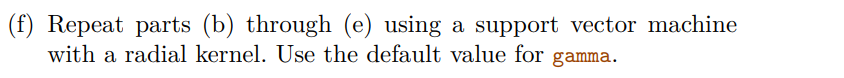

In [411]:
radial_svm = SVC(C=0.01, kernel="rbf").fit(X_train, y_train)

y_pred_train = radial_svm.predict(X_train)
y_pred_test = radial_svm.predict(X_test)

print(" ")
print(f"Train error rate with C=0.01: {1 - accuracy_score(y_train, y_pred_train)}")
print(f"Test error rate with C=0.01: {1 - accuracy_score(y_test, y_pred_test)}")
print(" ")

kfold = skm.KFold(n_splits=5,
                  random_state=0,
                  shuffle=True)

param_grid = {
  "C": [0.01, 0.1, 1, 5, 10]
}

grid = skm.GridSearchCV(radial_svm,
                        param_grid=param_grid,
                        cv=kfold,
                        refit=True,
                        scoring="accuracy") 

grid.fit(X, y)

best_radial_svm = grid.best_estimator_

print(" ")
print(f"Number of support vectors: {best_radial_svm.support_vectors_.shape}")

y_pred_train = best_radial_svm.predict(X_train)
y_pred_test = best_radial_svm.predict(X_test)

print(" ")
print(f"Train error rate with C={best_radial_svm.C}: {1 - accuracy_score(y_train, y_pred_train)}")
print(f"Test error rate with C={best_radial_svm.C}: {1 - accuracy_score(y_test, y_pred_test)}")
print(" ")

 
Train error rate with C=0.01: 0.375
Test error rate with C=0.01: 0.43333333333333335
 
 
Number of support vectors: (834, 17)
 
Train error rate with C=0.01: 0.375
Test error rate with C=0.01: 0.43333333333333335
 


In [412]:
poly_svm = SVC(C=0.01, kernel="rbf").fit(X_train, y_train)

y_pred_train = poly_svm.predict(X_train)
y_pred_test = poly_svm.predict(X_test)

print(" ")
print(f"Train error rate with C=0.01: {1 - accuracy_score(y_train, y_pred_train)}")
print(f"Test error rate with C=0.01: {1 - accuracy_score(y_test, y_pred_test)}")
print(" ")

kfold = skm.KFold(n_splits=5,
                  random_state=0,
                  shuffle=True)

param_grid = {
  "C": [0.01, 0.1, 1, 5, 10]
}

grid = skm.GridSearchCV(poly_svm,
                        param_grid=param_grid,
                        cv=kfold,
                        refit=True,
                        scoring="accuracy") 

grid.fit(X, y)

best_poly_svm = grid.best_estimator_

print(" ")
print(f"Number of support vectors: {best_poly_svm.support_vectors_.shape}")

y_pred_train = best_poly_svm.predict(X_train)
y_pred_test = best_poly_svm.predict(X_test)

print(" ")
print(f"Train error rate with C={best_poly_svm.C}: {1 - accuracy_score(y_train, y_pred_train)}")
print(f"Test error rate with C={best_poly_svm.C}: {1 - accuracy_score(y_test, y_pred_test)}")
print(" ")

 
Train error rate with C=0.01: 0.375
Test error rate with C=0.01: 0.43333333333333335
 
 
Number of support vectors: (834, 17)
 
Train error rate with C=0.01: 0.375
Test error rate with C=0.01: 0.43333333333333335
 


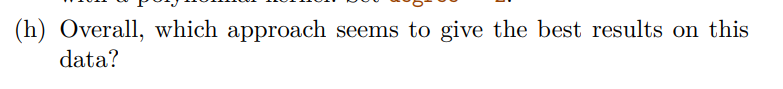

Linear SVM has the lowest error rate, so we can make assumption that data can be linear separeted without adding some complexity to build decision boundary